# Analysis of the unique two extremal projective planes with two punctures

There are exactly two extremal disc configurations associated to projective planes with two punctures and the side-pairing pattern of their associated extremal triangle groups are given by the following association of half-sides in the fundamental domain:

(1,3)(2,4)(5,9)(6,10)(7,11)(8,12)(13,16)(14,15), while the half-sides that share some vertex in the fundamental domain are given by (1,3)(2,5)(4,7)(6,10)(8,13)(9,11)(12,15)(14,16).

(1,3)(2,4)(5,9)(6,10)(7,11)(8,12)(13,15)(14,16), while the half-sides that share some vertex in the fundamental domain are given by (1,3)(2,5)(4,7)(6,12)(8,13)(9,11)(10,15)(14,16).

The half-sides of a same edge are given by (1,2)(3,4)(5,6)(7,8)(9,10)(11,12)(13,14)(15,16) in all the cases.

### The following cells are shared by all the extremal disc configurations. They include the functions needed for finding the centers of hidden extremal discs.

In [1]:
g=1 #Genus.
n=2 #Number of cusps.
b=0 #Number of boundary components.
m=6*g+4*n-6 #Number of sides of the fundamental domain.

half_alpha=find_root(2*sin(x)-cos(3*x)==0, 0.01, pi/m)

alpha=2*half_alpha #Measure of the angles in the equilateral triangles of DeBlois decomposition.
beta=N((pi-(m-n)*half_alpha)/n) #Measure of the positive angles of the horocyclic ideal triangles of DeBlois decomposition.
radius=arccosh(1/(2*sin(half_alpha))) #Extremal radius.

#Lengths and distances in the fundamental domain:
fd_half_edge=arccosh(cos(half_alpha)/sin(pi/3))
fd_edge=2*fd_half_edge #Length of the sides of type II.

fd_distance_vertex=N(arccosh((cos(half_alpha)*cos(pi/3))/(sin(half_alpha)*sin(pi/3))))
#Distance from the origin (the center of our fundamental domain) to the proper non-right vertices of the fundamental domain.
fd_first_distance, fd_second_distance=2*radius, 2*fd_distance_vertex+fd_edge #First two admissible distances.

#Euclidean version of all the lenghts and distances:
r_euc=tanh(radius/2)
fd_edge_euc=tanh(fd_edge/2)
fd_dist_vertex_euc=tanh(fd_distance_vertex/2)
second_distance_euc=tanh(fd_second_distance/2)

In [2]:
#The following function calculates the generalized circle that passes through three fixed points a,b,c of the hyperbolic plane.
#Inputs: a,b,c (points of the Poincaré disc model), col ('str', default=0), style ('str')
#Outputs: if col!=0, ThreePointsCircle returns the plot of the generalized circle C that passes through a,b,c of color col and linestyle style,
#while if col==0 it returns only the algebraic expression of C.

def ThreePointsCircle(a,b,c,col=0,style='-'): 
    x,y=var('x'), var('y')
    u,v,w=var('u'),var('v'),var('w')
    
    if a in PD:
        a_1=N(a.coordinates())
    else:
        a_1=N(a)
    if b in PD:
        b_1=N(b.coordinates())
    else:
        b_1=N(b)
    if c in PD:
        c_1=N(c.coordinates())
    else:
        c_1=N(c)
        
    if abs((a_1-b_1)*(b_1-c_1)*(c_1-a_1))<10^(-5): return 'The three points introduced are not all different.'
    else:
        if abs(((c_1-a_1)/(b_1-a_1)).imag())<10^(-5): 
            if abs((b_1).real()-(a_1).real())>10^(-5):
                circle=(y-u*x-v==0)
                coc=(a_1.imag()-b_1.imag())/(a_1.real()-b_1.real())
                eq=circle.subs(u=coc).subs(v=a_1.imag()-a_1.real()*coc)
            else:
                eq=(x-a_1.real()==0)
        else:
            circle=((x-u)^2+(y-v)^2-w^2==0)
            eq1=circle.subs(x==a_1.real()).subs(y==a_1.imag())
            eq2=circle.subs(x==b_1.real()).subs(y==b_1.imag())
            eq3=circle.subs(x==c_1.real()).subs(y==c_1.imag())
            coef=solve([eq1,eq2,eq3],u,v,w)
            control=min(abs(N(coef[1][0].rhs())),abs(N(coef[1][1].rhs())),abs(N(coef[1][2].rhs())))
            if control>10^10: circle=((u/v)*x+y+(u^2+v^2-w^2)/(-2*v)==0)
            eq=circle.subs(u=N(coef[1][0].rhs())).subs(v=N(coef[1][1].rhs())).subs(w=N(coef[1][2].rhs()))
        
        if col==0: return eq
        else:
            return implicit_plot(eq, (x,-1,1), (y,-1,1), color=col, axes=false, linestyle=style, linewidth=0.5)

In [3]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a hyperbolic isometry or a glide-reflection.
#Inputs: s (hyperbolic isometry or glide-reflection), d ('float'), c ('str', default=0)
#Outputs: if c!=0, banana returns the plot of the bananas of the isometry s associated to the distance d in color c, while if c==0 it returns the algebraic expression of the bananas.

def banana(s,d,c=0):
    origin=PD.get_point(0+0*I)
    T=N((s*s).translation_length()/2)
    
    if bool(abs(T-d)<10^(-5)):
        if bool(c==0)==false:
            return plot(s.axis(), color=c)
        else:
            return s.axis()
        
    if bool(s.classification()=='hyperbolic'):
        dist_banana_axis=N(arccosh(sinh(d/2)/sinh(T/2)))
    elif bool(s.classification()=='orientation-reversing hyperbolic'):
        dist_banana_axis=N(arccosh(cosh(d/2)/cosh(T/2)))
        
    initial,final=N((s*s).axis().ideal_endpoints()[0].coordinates()),N((s*s).axis().ideal_endpoints()[1].coordinates())
    middle=(initial+final)/2
    if abs(middle)<10^(-5):
        border_1, border_2= cos(arg(initial)+pi/2)+I*sin(arg(initial)+pi/2), cos(arg(initial)+3*pi/2)+I*sin(arg(initial)+3*pi/2)
    else:
        border_1=cos(arg(middle))+I*sin(arg(middle))
        border_2=-border_1

    dist_origin_axis=(s*s).axis().dist(origin)
    
    if bool(d>T) or bool(abs(d-T)<10^(-5)):
        mod_1=tanh(abs(dist_origin_axis-dist_banana_axis)/2)
        mod_2=tanh((dist_origin_axis+dist_banana_axis)/2)
        argu=arg(border_1)
        if bool(dist_banana_axis<dist_origin_axis) or bool(abs(dist_banana_axis-dist_origin_axis)<10^(-5)):
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu)+I*sin(argu)), c)
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c)
        else:
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu+pi)+I*sin(argu+pi)), c, '-')
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c, ':')
        if bool(c==0)==false:
            return part_1+part_2
        else:
            return [part_1,part_2]
    else:
        return 'ERROR'

In [4]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a parabolic isometry.
#Inputs: theta ('float'), distances (list of lists [[a_1,...], [a_2,...],...,[a_n,...]] with ai an unsigned float), m ('int'), c ('str', default=0)
#Outputs: if c!=0, bananapar returns the plot of the banana of a parabolic isometry fixing the ideal point exp(I*theta) and associated to the distance distances[m][0] in color c,
#while if c==0 it returns only the algebraic expression of the banana.

def bananapar(theta,distances,m,c=0):
    var('x y')
    a=cos(theta)
    b=sin(theta)
    d=sinh(distances[0][0]/2)/sinh(distances[m][0]/2)
    
    #Poisson kernel: P(z,w)=(1-|z|^2)/|z-w|^2=Re(f(z)) with f(z)=(w+z)/(w-z).
    z1=(d*a+sqrt(1-b^2*d^2))/(d+1)
    z2=(d*a-sqrt(1-b^2*d^2))/(d+1)
    
    if abs(theta)>10^(-5) and abs(theta-pi)>10^(-5):
        lambda1=(z1^2-1)/(2*(z1*a-1))
        lambda2=(z2^2-1)/(2*(z2*a-1))
    elif abs(theta-pi)<=10^(-5):
        lambda1=(1-z1)/2
        lambda2=(1-z2)/2
    else:
        lambda1=(z1+1)/2
        lambda2=(z2+1)/2

    eq1=(x-lambda1*a)^2+(y-lambda1*b)^2-(1-lambda1)^2
    eq2=(x-lambda2*a)^2+(y-lambda2*b)^2-(1-lambda2)^2
    if c==0: return (eq1,eq2)
    else: return implicit_plot(eq1==0, (x, -1, 1), (y, -1, 1), color=c, linestyle='--', linewidth=0.5)+implicit_plot(eq2==0, (x, -1, 1), (y, -1, 1), color=c,linewidth=0.5)

In [5]:
#The following function returns the intersection points of two generalized circles in the hyperbolic plane.
#Inputs: pol1,pol2 ('symbolic expressions')
#Outputs: list of points in the hyperbolic plane in which the generalized circles pol1==0 and pol2==0 intersect.

def coord_intersection(pol1,pol2):
    x,y=var('x'), var('y')
    R=PolynomialRing(RR,['x','y'])
    gr1,gr2=2,2
    if R(pol1).coefficient({x:0,y:2})==0 and R(pol1).coefficient({x:2,y:0})==0:
        gr1=1
    if R(pol2).coefficient({x:0,y:2})==0 and R(pol2).coefficient({x:2,y:0})==0:
        gr1=1
    
    if gr1==1 and gr2==1:
        sol=solve([pol1,pol2],x,y)
        solution=[N(sol[0][0].rhs())+N(sol[0][1].rhs())*I]
        return [z for z in solution if abs(z)<=1]
    
    elif gr1==2 and gr2==2:
        sol=solve([pol1,pol1-pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []
        
    else:
        sol=solve([pol1,pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []

In [6]:
#The following function returns the elliptic isometry of order 2 in the hyperbolic plane that relates two given points.
#Inputs: p,q (points in the Poincaré disc model)
#Outputs: Elliptic isometry of order two that sends p to q and viceversa.

def rotationpi(p,q):
    p1=PD.get_point(p)
    q1=PD.get_point(q)
    geod=PD.get_geodesic(p1,q1)
    mid_point=geod.midpoint().coordinates()
    
    rot_matrix=matrix([[I, mid_point*(-I)], [mid_point.conjugate()*I, -I]])
    rotation=PD.get_isometry(rot_matrix)
    
    can_matrix=matrix([[I, 0], [0, -I]])
    can_rotation=PD.get_isometry(can_matrix)
    rotationpi=rotation*can_rotation*rotation^(-1)
    return rotationpi

## Configuration 1

In [7]:
#Vertices and edges of the fundamental domain:
PD=HyperbolicPlane().PD()

fd_vertices=[1+0*I]
fd_vertices+=[fd_dist_vertex_euc*(cos(beta+half_alpha)+I*sin(beta+half_alpha))]
fd_vertices+=[cos(2*beta+alpha)+I*sin(2*beta+alpha)]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+3*half_alpha)+I*sin(3*beta+3*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+5*half_alpha)+I*sin(3*beta+5*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+7*half_alpha)+I*sin(3*beta+7*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+9*half_alpha)+I*sin(3*beta+9*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+11*half_alpha)+I*sin(3*beta+11*half_alpha))]

fd_edges=[PD.get_geodesic(fd_vertices[k],fd_vertices[k+1]) for k in [0..m-2]]+[PD.get_geodesic(fd_vertices[m-1],fd_vertices[0])]

fd_midpoints=[(r_euc-0.03)*(cos(beta)-I*sin(beta))]
fd_midpoints+=[(r_euc-0.03)*(cos(beta)+I*sin(beta))]
fd_midpoints+=[(r_euc-0.03)*(cos(beta+alpha)+I*sin(beta+alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*beta+alpha)+I*sin(3*beta+alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*beta+k*alpha)+I*sin(3*beta+k*alpha)) for k in [2..5]]

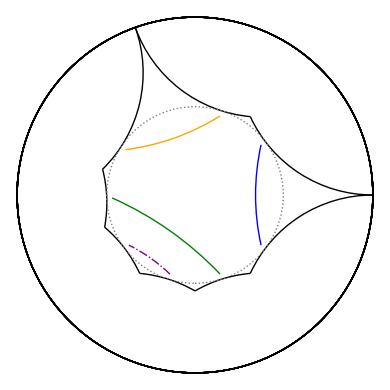

In [8]:
identifications=plot(PD.get_geodesic(fd_midpoints[0],fd_midpoints[1]), color='blue')
identifications+=plot(PD.get_geodesic(fd_midpoints[2],fd_midpoints[3]), color='orange')
identifications+=plot(PD.get_geodesic(fd_midpoints[4],fd_midpoints[7]), color='green')
identifications+=plot(PD.get_geodesic(fd_midpoints[5],fd_midpoints[6]), color='purple', linestyle='-.')

polygon=Graphics()
for edge in fd_edges:
    polygon+=plot(edge, axes=false, color='black')

fundamental_domain=polygon+identifications

fundamental_domain+circle((0,0), r_euc, color='gray', thickness=1, linestyle='dotted')

In [9]:
#Definition of the side-pairing transformations:
ref=[]
for j in [0..m-1]:
    ref.append(fd_edges[j].reflection_involution())

rot1=PD.get_isometry(matrix(2,[e^(I*half_alpha),0,0,e^(-I*half_alpha)])) 
    
simbas1=PD.get_geodesic(PD(fd_vertices[0]),PD(0+0*I)).reflection_involution()
simbas2=PD.get_geodesic(PD(fd_vertices[2]),PD(0+0*I)).reflection_involution()
simbas3=PD.get_geodesic(PD(fd_vertices[5]),PD(0+0*I)).reflection_involution()

side_pairings=[simbas1*ref[0],simbas2*ref[1],simbas2*ref[2],simbas3*ref[3],rot1*ref[4],rot1^(-1)*ref[5],simbas3*ref[6]]
side_pairings+=[simbas1*ref[7]]

In [10]:
#The following function plots the image of polygon by an isometry.
#Inputs: g (isometry in the Poincaré disc model), col ('str'), style ('str', default='-'), w ('float', default='1')
#Outputs: It returns a figure with the image by g of the fundamental domain, where the lines have color col, linestyle style and thickness w.

def movepolygon(g, col, style='-', w=1):
    global fd_edges
    g_fd=Graphics()
    g_fd_edges=[g*edge for edge in fd_edges]
    for j in [0..m-1]:
        g_fd+=plot(g_fd_edges[j], color=col, axes=False, linestyle=style, thickness=w)
    return g_fd

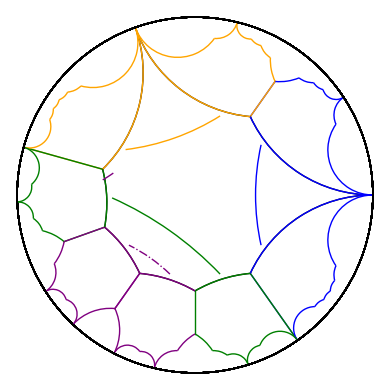

In [11]:
polygon_color=fundamental_domain
list1=[0,1,3,4]
col1=['blue','orange','green','purple']

for j in [0..3]:
    polygon_color+=movepolygon(side_pairings[list1[j]], col1[j])+movepolygon(side_pairings[list1[j]]^(-1), col1[j])
polygon_color

### Search of the preimages of extremal disc centers using the "bananas' method".

In [12]:
#Construction of a short list of admissible distances:
lst_index=[[j] for j in [0..m-1]]
origin=PD(0+0*I)
ln=2

for i in range(ln):
    lst_index_aux=copy(lst_index)
    for lst in lst_index_aux:
        for j in [0..m-1]:
            lst_index+=[lst+[j]]

distances_list=[]
pnts=[origin]
simbas=PD.get_geodesic(1,-1).reflection_involution()

for lst in lst_index: #Construction of isometries given as the product of at most three side-pairings of the fundamental domain.
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings[lst[j]]
    pt=g*origin
    distances_list+=[(origin.dist(pt), lst, g , g.classification())]
    pnts+=[pt]

In [13]:
#Refinement of the distances in distances_list, taking out the elements that repeat previous admissible distances:
distances_list.sort()
distances_list_ref=[]
k=0

while distances_list[k][0]==0: k+=1

distances_list_ref+=[distances_list[k]]

for j in [k..len(distances_list)-2]:
    if abs(distances_list[j+1][0]-distances_list[j][0])>10^(-5):
        distances_list_ref+=[distances_list[j+1]]
len(distances_list_ref)

51

In [14]:
#The first two distances of distances_list_ref coincide with the first two admissible distances we know theoretically.
abs(distances_list_ref[0][0]-fd_first_distance), N(abs(distances_list_ref[1][0]-fd_second_distance))

(1.28785870856518e-14, 2.10942374678780e-15)

In [15]:
#Refinement of the isometries in distances_list, taking out the elements that repeat previous isometries:
list_by_distances=[[] for j in [0..len(distances_list_ref)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref[0][0]

for j in [k..len(distances_list)-1]:
    if abs(distances_list[j][0]-d)<10^(-3): list_by_distances[l]+=[distances_list[j]]
    else:
        list_by_distances[l+1]+=[distances_list[j]]
        l+=1
        d=distances_list_ref[l][0]
        
isometries_t=[]
for k in [0..len(list_by_distances)-1]:
    isometries=[]
    for j in [0..len(list_by_distances[k])-1]:
        test=0
        s=0
        isometry=list_by_distances[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t+=isometries

Once we have computed a reasonable amount of admissible distances of this extremal disc configuration, we are going to plot the a set of bananas needed to cover the whole fundamental domain with the closure of the regions they bound.

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/plot/contour_plot.py:208: UserWarning: No contour levels were found within the data range.
  linewidths=linewidths, linestyles=linestyles)


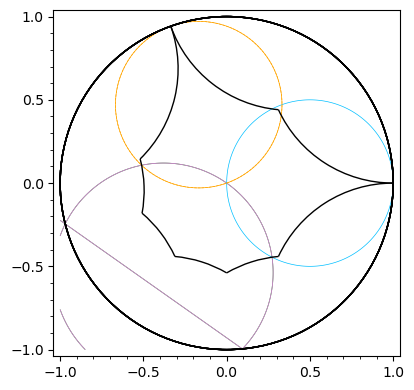

In [16]:
good_side_pairings=[]

for g in side_pairings:
    if g.classification()=='hyperbolic' or g.classification()=='orientation-reversing hyperbolic':
        good_side_pairings.append(g)

polygon_bananas1=polygon

col1=['deepskyblue','orange','green','violet']

for j in [0..1]:
    polygon_bananas1+=banana(good_side_pairings[j],2*radius,col1[j+2])

polygon_bananas1+=bananapar(0,distances_list_ref,0,col1[0])
polygon_bananas1+=bananapar(2*beta+alpha,distances_list_ref,0,col1[1])
    
polygon_bananas1.show(ymax=1, ymin=-1)

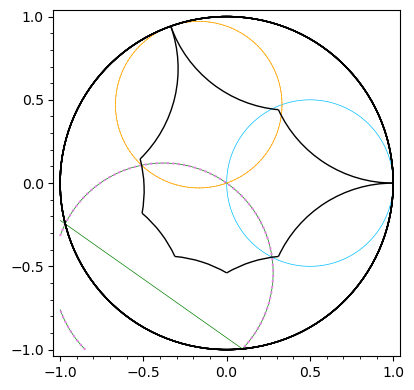

In [17]:
#Observation: the first admissible purple banana coincides with the first admissible green banana.
polygon_bananas1_0=polygon

polygon_bananas1_0+=banana(good_side_pairings[0],2*radius,col1[2])
polygon_bananas1_0+=bananapar(0,distances_list_ref,0,col1[0])
polygon_bananas1_0+=bananapar(2*beta+alpha,distances_list_ref,0,col1[1])

polygon_bananas1_0+=implicit_plot(banana(good_side_pairings[1],2*radius)[0], (x,-1,1), (y,-1,1), color=col1[3], linestyle=':')
polygon_bananas1_0.show(ymax=1, ymin=-1)

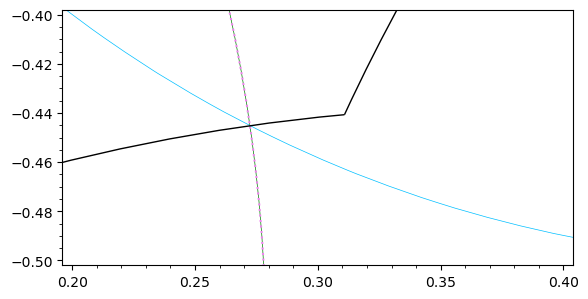

In [18]:
polygon_bananas1_0.show(ymax=-0.4, ymin=-0.5, xmax=0.4, xmin=0.2)

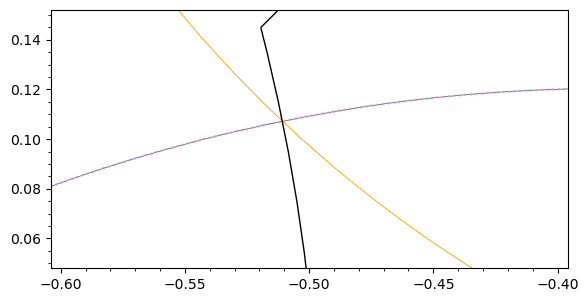

In [19]:
polygon_bananas1_0.show(ymax=0.15, ymin=0.05, xmax=-0.4, xmin=-0.6)

As fd_first_distance is the smallest admissible distance, we do not have to calculate more bananas: if d1\<d2, the bananas of a hyperbolic isometry (or glide reflection) s associated to the distance d1 are contained in the region bounded by the bananas of s associated to the distance d2, while the banana of a parabolic transformation s associated to d1 is a horocycle contained in the horoball bounded by the banana of s associated to the distance d2. Therefore, as the closure of the regions bounded by the bananas represented in the previous figure cover the whole fundamental domain, we do not have to take more bananas: if a point is at the interior of the region bounded by the bananas associated to the distance fd_first_distance, there is no admissible banana of this side-pairing that passes through this point.

In particular, the preimages of the extremal disc centers must be on the bananas illustrated in the previous figure. In fact, if we consider the open sets given by the interior of the regions described previously and we take their union, we will be covering all the points of the fundamental domain except three, one of them the origin (which we know is the preimage of an extremal disc centre by construction). Therefore, we only need to analyse the situation of this pair of special points, which is the only other candidates to be the preimage of an extremal disc center. Observe that these points are in the boundary of the fundamental domain and they are identified by an element in the uniformizing group.

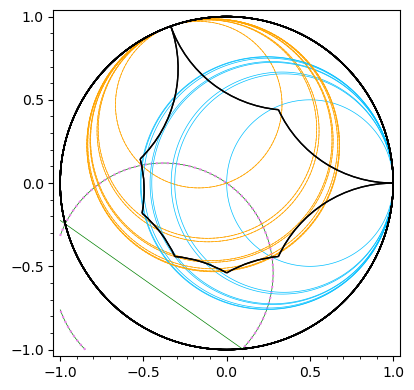

In [20]:
polygon_bananas1_2=polygon_bananas1_0

for k in [1..7]:
    polygon_bananas1_2+=bananapar(0,distances_list_ref,k,'deepskyblue')
    polygon_bananas1_2+=bananapar(2*beta+alpha,distances_list_ref,k,'orange')

(polygon+polygon_bananas1_2).show(ymax=1, ymin=-1)

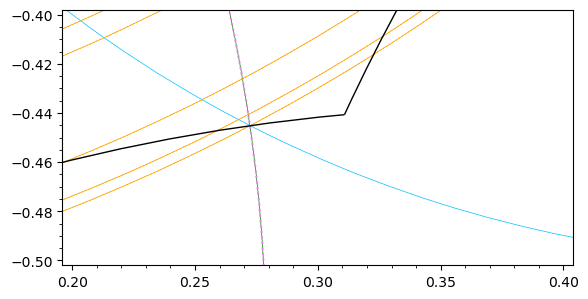

In [21]:
polygon_bananas1_2.show(ymax=-0.4, ymin=-0.5, xmax=0.4, xmin=0.2) #We have a candidate!

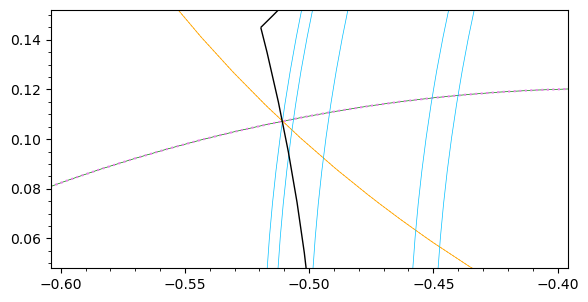

In [22]:
polygon_bananas1_2.show(ymax=0.15, ymin=0.05, xmax=-0.4, xmin=-0.6)
#We have another candidate! (It is identified with the previous one by an element in the uniformizing group)

There are bananas of all the colors intersecting in the two unique possible candidates (distinct to the origin) for being the preimage of an extremal disc center in the fundamental domain. As they are identified by an element in the uniformizing group, we only have to study the situation at one of these points.

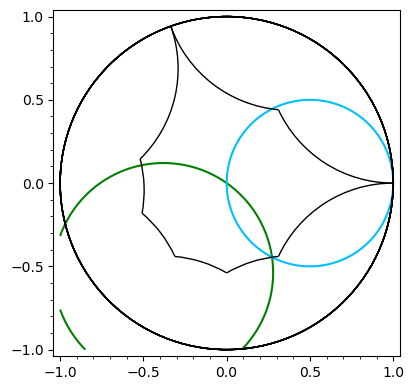

In [23]:
banana1_1=banana(good_side_pairings[0],2*radius)[0]
banana2_1=bananapar(0,distances_list_ref,0)[1]==0

implicit_plot(banana1_1,(x, -1, 1),(y, -1, 1),color=col1[2])+implicit_plot(banana2_1,(x, -1, 1),(y, -1, 1),color='deepskyblue')+polygon

In [24]:
intersection=coord_intersection(banana1_1,banana2_1)
intersection

[-3.05311331771918e-16 - 8.32667268468867e-16*I,
 0.272394215502257 - 0.445191651834541*I]

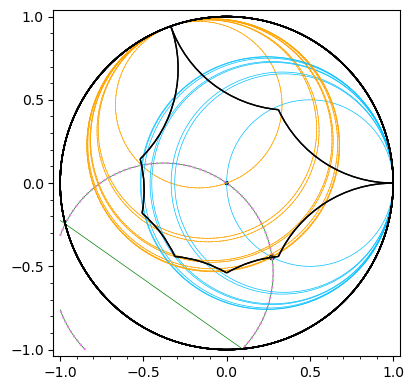

In [25]:
intersection_p=intersection[1]
bananas_point=polygon+polygon_bananas1_2+points([intersection_p],color='black', size='20')+points([0+0*I],color='black')
bananas_point.show(ymin=-1,ymax=1)

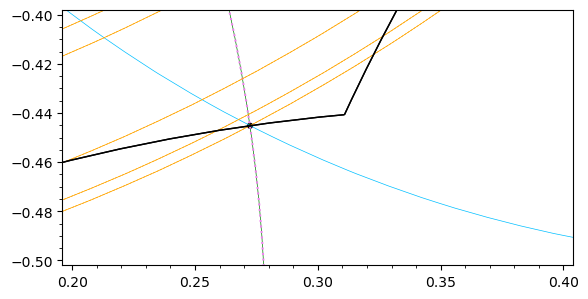

In [26]:
bananas_point.show(ymax=-0.4, ymin=-0.5, xmax=0.4, xmin=0.2)

In [27]:
#Check if the rotation of angle pi around the origin defines an automorphism of the surface.
rot=rotationpi(0+0*I, intersection_p)
geod=PD.get_geodesic(PD.get_point(0+0*I), PD.get_point(intersection_p))
fixed_p=geod.midpoint().coordinates()

intersection_p, fixed_p

(0.272394215502257 - 0.445191651834541*I,
 0.14700188482169393 - 0.2402547785601512*I)

In [28]:
#The following function find out if an isometry conjugates another isometry in an element of a fixed list of isometries.
#Inputs: generators (list of isometries of the hyperbolic plane), isometries (list of isometries of the hyperbolic plane), aut (isometry of the hyperbolic plane), k ('int')
#Outputs: A message about if g=aut*generators[k]*aut^(-1) equals some element in isometries or it is impossible to occur because metric conditions (it does not respect the tessellation defined by generators).
#In any of the previous cases, it returns the isometry h that give us the information and plot the image of the fundamental domain by h^(-1)*g.

def check_conj(generators,isometries,aut,k):
    conj=aut*generators[k]*aut^(-1)
    k=0
    test=0
    
    while k<len(isometries) and test==0:
        dist=origin.dist(isometries[k]^(-1)*conj*origin)
        if dist<radius:
            test=1
        k+=1
    
    if test==0: print("We have arrived to the end of the list without finding any element that confirms or denies anything.")
    else:
        print("The right element corresponds to the position ", k-1)
        print("The isometry is given by: ", isometries[k-1])
        if dist<10^(-6) and PD(1/2).dist((isometries[k-1]^(-1)*conj)*PD(1/2))<10^(-6) and (isometries[k-1]^(-1)*conj).preserves_orientation()==True:
            print("It conjugates well.")
        show(polygon+movepolygon((isometries[k-1]^(-1)*conj), 'skyblue'))

The right element corresponds to the position  5
The isometry is given by:  Isometry in PD
[  0.9532005682191862 + 1.3514358294070887*I  1.2555392470987186 - 0.39823526118789093*I]
[-1.2555392470987186 - 0.39823526118789093*I  -0.9532005682191862 + 1.3514358294070887*I]


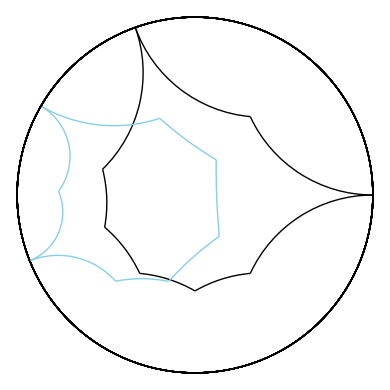

In [29]:
candidate_aut=rot
check_conj(side_pairings,isometries_t,candidate_aut,0) #It does not conjugate properly.

In [30]:
num=0 #We try with a different lifting.

rot=rotationpi((side_pairings[num]*origin).coordinates(), intersection_p)
geod=PD.get_geodesic((side_pairings[num]*origin).coordinates(), intersection_p)
fixed_p=geod.midpoint().coordinates()

intersection_p, fixed_p

(0.272394215502257 - 0.445191651834541*I,
 0.486801938996170 - 0.445191651834541*I)

Checking if rot conjugates properly the side-pairing transformation number  0
The right element corresponds to the position  40
The isometry is given by:  Isometry in PD
[-1.0000000000000244 - 4.152757602010433*I  3.3935614475120066 + 2.393561447511992*I]
[ 3.3935614475120066 - 2.393561447511992*I -1.0000000000000244 + 4.152757602010433*I]
It conjugates well.


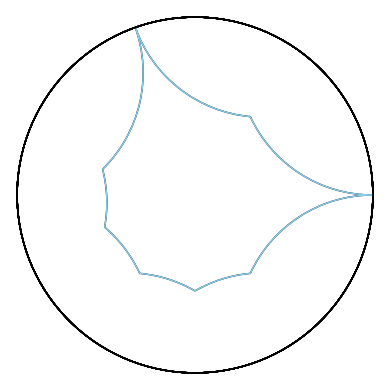

Checking if rot conjugates properly the side-pairing transformation number  1
We have arrived to the end of the list without finding any element that confirms or denies anything.
Checking if rot conjugates properly the side-pairing transformation number  2
We have arrived to the end of the list without finding any element that confirms or denies anything.
Checking if rot conjugates properly the side-pairing transformation number  3
The right element corresponds to the position  163
The isometry is given by:  Isometry in PD
[1.31718264650677 - 9.93988049703448*I 5.71074409401881 + 8.18068434253603*I]
[5.71074409401881 - 8.18068434253603*I 1.31718264650677 + 9.93988049703448*I]
It conjugates well.


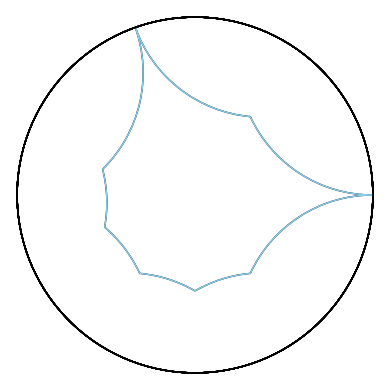

Checking if rot conjugates properly the side-pairing transformation number  4
The right element corresponds to the position  239
The isometry is given by:  Isometry in PD
[ -10.2711702601799 + 7.17006334017776*I  12.4799100754978 + 0.398235261187891*I]
[-12.4799100754978 + 0.398235261187891*I   10.2711702601799 + 7.17006334017776*I]
It conjugates well.


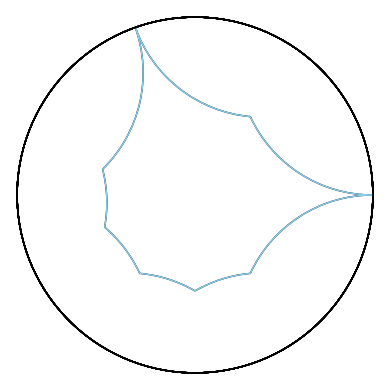

Checking if rot conjugates properly the side-pairing transformation number  5
The right element corresponds to the position  237
The isometry is given by:  Isometry in PD
[ -10.2711702601799 + 7.17006334017777*I  12.4799100754978 - 0.398235261187890*I]
[-12.4799100754978 - 0.398235261187890*I   10.2711702601799 + 7.17006334017777*I]
It conjugates well.


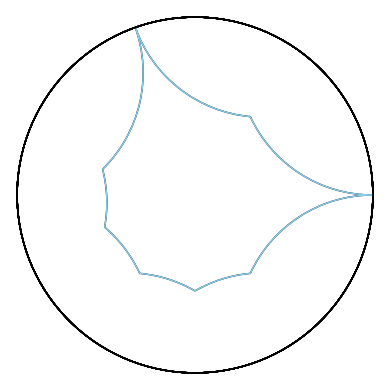

Checking if rot conjugates properly the side-pairing transformation number  6
The right element corresponds to the position  168
The isometry is given by:  Isometry in PD
[-1.31718264650677 - 9.93988049703448*I  5.71074409401881 + 8.18068434253604*I]
[ 5.71074409401881 - 8.18068434253604*I -1.31718264650677 + 9.93988049703448*I]
It conjugates well.


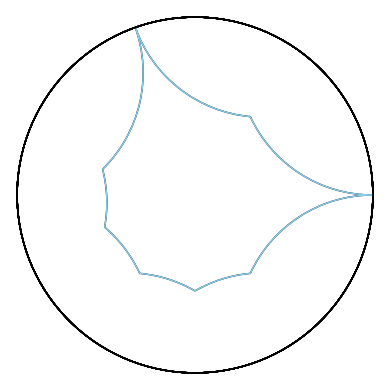

Checking if rot conjugates properly the side-pairing transformation number  7
The right element corresponds to the position  44
The isometry is given by:  Isometry in PD
[1.00000000000003 - 4.15275760201043*I 3.39356144751201 + 2.39356144751199*I]
[3.39356144751201 - 2.39356144751199*I 1.00000000000003 + 4.15275760201043*I]
It conjugates well.


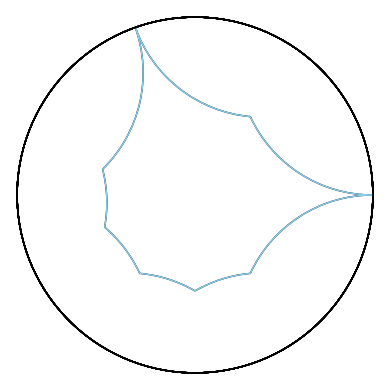

In [31]:
candidate_aut=rot
for j in [0..m-1]:
    print('Checking if rot conjugates properly the side-pairing transformation number ', j)
    check_conj(side_pairings,isometries_t,candidate_aut,j)

The algorithm does not converge for side_pairings[1] and side_pairings[2] if we only consider the elements in the uniformizing group given as the product of at most three side-pairings. We will try to apply the algorithm considering the isometries given as the product of four side-pairings.

In [32]:
lst_index_of4=[[i,j,k,l] for i in [0..7] for j in [0..7] for k in [0..7] for l in [0..7]]

distances_list_of4=[]
for lst in lst_index_of4:
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings[lst[j]]
    pt=g*origin
    distances_list_of4+=[(origin.dist(pt), lst, g , g.classification())]

In [33]:
distances_list_of4.sort()
distances_list_ref_of4=[]
k0=0

while distances_list_of4[k0][0]==0: k0+=1

distances_list_ref_of4+=[distances_list_of4[k0]]

for j in [k0..len(distances_list_of4)-2]:
    if abs(distances_list_of4[j+1][0]-distances_list_of4[j][0])>10^(-5):
        distances_list_ref_of4+=[distances_list_of4[j+1]]
len(distances_list_ref_of4)

293

In [34]:
#Refinement of the isometries in distances_list4, taking out the elements that repeat previous isometries:
list_by_distances_of4=[[] for j in [0..len(distances_list_ref_of4)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref_of4[0][0]

for j in [k0..len(distances_list_of4)-1]:
    if abs(distances_list_of4[j][0]-d)<10^(-3): list_by_distances_of4[l]+=[distances_list_of4[j]]
    else:
        list_by_distances_of4[l+1]+=[distances_list_of4[j]]
        l+=1
        d=distances_list_ref_of4[l][0]

isometries_t_of4=[]
for k in [0..len(list_by_distances_of4)-1]:
    isometries=[]
    for j in [0..len(list_by_distances_of4[k])-1]:
        test=0
        s=0
        isometry=list_by_distances_of4[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t_of4+=isometries

Checking if rot conjugates properly the side-pairing transformation number  1
The right element corresponds to the position  1068
The isometry is given by:  Isometry in PD
[1.00000000000003 - 29.5024588445968*I 20.3613686850721 + 21.3497012425863*I]
[20.3613686850721 - 21.3497012425863*I 1.00000000000003 + 29.5024588445968*I]
It conjugates well.


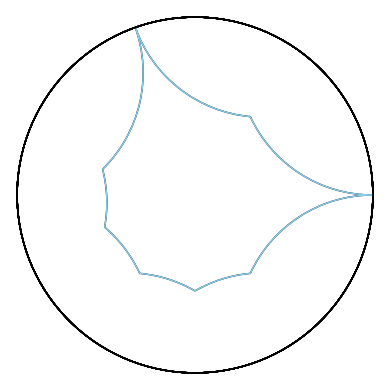

Checking if rot conjugates properly the side-pairing transformation number  2
The right element corresponds to the position  1070
The isometry is given by:  Isometry in PD
[-1.00000000000002 - 29.5024588445968*I  20.3613686850721 + 21.3497012425863*I]
[ 20.3613686850721 - 21.3497012425863*I -1.00000000000002 + 29.5024588445968*I]
It conjugates well.


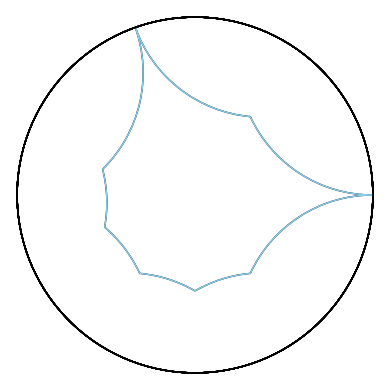

In [35]:
for j in [1..2]:
    print('Checking if rot conjugates properly the side-pairing transformation number ', j)
    check_conj(side_pairings,isometries_t_of4,candidate_aut, j)

In the eight previous cases, the algorithm of check_conj converges and mustbeidentity is an isometry that fixes at least two points and preserves the orientation, so mustbeidentity==Id. Therefore, candidate_aut belongs to the normalizer of the uniformizating group and it defines an automorphism of the surface.

Moreover, the image of the projection of the origin by this automorphism is also an extremal disc center and intersection_p (and its identified one) is a preimage of this point. As the origin and intersection_p were the only candidates to be the preimage of an extremal disc center in the fundamental domain, the extremal projective plane with two cusps defined by this extremal disc configuration has exactly two extremal discs, centered at the projections of the origin and intersection_p.

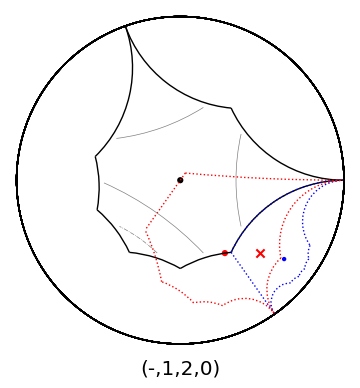

In [36]:
identifications_g=plot(PD.get_geodesic(fd_midpoints[0],fd_midpoints[1]), color='gray', thickness=0.5)
identifications_g+=plot(PD.get_geodesic(fd_midpoints[2],fd_midpoints[3]), color='gray', thickness=0.5)
identifications_g+=plot(PD.get_geodesic(fd_midpoints[4],fd_midpoints[7]), color='gray', thickness=0.5)
identifications_g+=plot(PD.get_geodesic(fd_midpoints[5],fd_midpoints[6]), color='gray', linestyle='-.', thickness=0.5)

polygon_art=polygon+identifications_g+points([intersection_p], color='red',size=20)+points([0+0*I], color='black', size=20)
polygon_art+=points([fixed_p], marker='x', size=35, color='red')+text('(-,1,2,0)', (0,-1.15), fontsize='x-large', color='black')
polygon_art+=points([(side_pairings[num]*origin).coordinates()])+movepolygon(side_pairings[num], 'blue', ':', 1)
polygon_art+=movepolygon(candidate_aut*side_pairings[num],'red',':')
polygon_art

## Configuration 2

In [37]:
#Vertices and edges of the fundamental domain:
PD=HyperbolicPlane().PD()

fd_vertices2=[1+0*I]
fd_vertices2+=[fd_dist_vertex_euc*(cos(beta+half_alpha)+I*sin(beta+half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(beta+3*half_alpha)+I*sin(beta+3*half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(beta+5*half_alpha)+I*sin(beta+5*half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(beta+7*half_alpha)+I*sin(beta+7*half_alpha))]
fd_vertices2+=[cos(2*beta+4*alpha)+I*sin(2*beta+4*alpha)]
fd_vertices2+=[fd_dist_vertex_euc*(cos(3*beta+9*half_alpha)+I*sin(3*beta+9*half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(3*beta+11*half_alpha)+I*sin(3*beta+11*half_alpha))]

fd_edges2=[PD.get_geodesic(fd_vertices2[k],fd_vertices2[k+1]) for k in [0..m-2]]+[PD.get_geodesic(fd_vertices2[m-1],fd_vertices2[0])]

fd_midpoints2=[(r_euc-0.03)*(cos(beta)-I*sin(beta))]
fd_midpoints2+=[(r_euc-0.03)*(cos(beta)+I*sin(beta))]
fd_midpoints2+=[(r_euc-0.03)*(cos(beta+alpha)+I*sin(beta+alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(beta+2*alpha)+I*sin(beta+2*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(beta+3*alpha)+I*sin(beta+3*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(beta+4*alpha)+I*sin(beta+4*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*beta+4*alpha)+I*sin(3*beta+4*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*beta+5*alpha)+I*sin(3*beta+5*alpha))]

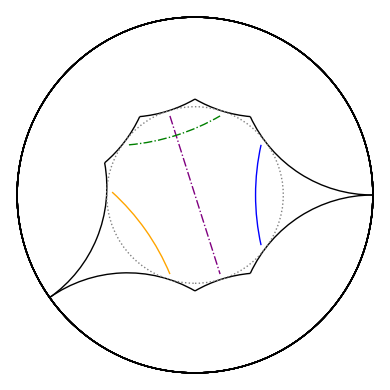

In [38]:
identifications2=plot(PD.get_geodesic(fd_midpoints2[0],fd_midpoints2[1]), color='blue')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[2],fd_midpoints2[4]), color='green', linestyle='-.')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[3],fd_midpoints2[7]), color='purple', linestyle='-.')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[5],fd_midpoints2[6]), color='orange')

polygon2=Graphics()
for edge in fd_edges2:
    polygon2+=plot(edge, axes=false, color='black')

fundamental_domain2=polygon2+identifications2

fundamental_domain2+circle((0,0), r_euc, color='gray', thickness=1, linestyle='dotted')

In [39]:
#Definition of the side-pairing transformations:
ref2=[]
for j in [0..m-1]:
    ref2.append(fd_edges2[j].reflection_involution())

rot2_1=PD.get_isometry(matrix(2,[e^(I*half_alpha),0,0,e^(-I*half_alpha)]))
rot2_2=PD.get_isometry(matrix(2,[e^(I*(beta+half_alpha)/2),0,0,e^(-I*(beta+half_alpha)/2)]))

simbas2_1=PD.get_geodesic(PD(fd_vertices2[0]),PD(0+0*I)).reflection_involution()
simbas2_2=PD.get_geodesic(PD(fd_vertices2[5]),PD(0+0*I)).reflection_involution()

side_pairings2=[simbas2_1*ref2[0],rot2_1^2*ref2[1],rot2_1^2*rot2_2^2*ref2[2],rot2_1^(-2)*ref2[3],simbas2_2*ref2[4]]
side_pairings2+=[simbas2_2*ref2[5],rot2_1^(-2)*rot2_2^(-2)*ref2[6],simbas2_1*ref2[7]]

In [40]:
#The following function plots the image of polygon2 by an isometry.
#Inputs: g (isometry in the Poincaré disc model), col ('str'), style ('str', default='-'), w ('float', default='1')
#Outputs: It returns a figure with the image by g of the fundamental domain, where the lines have color col, linestyle style and thickness w.
def movepolygon2(g, col, style='-', w=1):
    global fd_edges2
    g_fd=Graphics()
    g_fd_edges=[g*edge for edge in fd_edges2]
    for j in [0..m-1]:
        g_fd+=plot(g_fd_edges[j], color=col, axes=False, linestyle=style, thickness=w)
    return g_fd

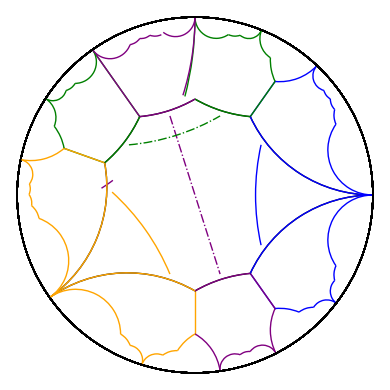

In [41]:
polygon_color2=fundamental_domain2
list2=[0,1,2,4]
col2=['blue','green','purple','orange']
for j in [0..3]:
    polygon_color2+=movepolygon2(side_pairings2[list2[j]], col2[j])+movepolygon2(side_pairings2[list2[j]]^(-1), col2[j])
polygon_color2

### Search of the preimages of extremal disc centers using the "bananas' method".

In [42]:
#Construction of a short list of admissible distances:
lst_index2=[[j] for j in [0..m-1]]
origin=PD(0+0*I)
ln=2

for i in range(ln):
    lst_index_aux=copy(lst_index2)
    for lst in lst_index_aux:
        for j in [0..m-1]:
            lst_index2+=[lst+[j]]

distances_list2=[]
simbas=PD.get_geodesic(1,-1).reflection_involution()

for lst in lst_index2: #Construction of isometries given as the product of at most three side-pairings of the fundamental domain.
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings2[lst[j]]
    pt=g*origin
    distances_list2+=[(origin.dist(pt), lst, g , g.classification())]

In [43]:
#Refinement of the distances in distances_list2, taking out the elements that repeat previous admissible distances:
distances_list2.sort()
distances_list_ref2=[]
k=0

while distances_list2[k][0]==0: k+=1

distances_list_ref2+=[distances_list2[k]]

for j in [k..len(distances_list2)-2]:
    if abs(distances_list2[j+1][0]-distances_list2[j][0])>10^(-5):
        distances_list_ref2+=[distances_list2[j+1]]
len(distances_list_ref2)

39

In [44]:
#The first two distances of distances_list_ref2 coincide with the first two admissible distances we know theoretically.
abs(distances_list_ref2[0][0]-fd_first_distance), N(abs(distances_list_ref2[1][0]-fd_second_distance))

(1.46549439250521e-14, 7.77156117237610e-16)

In [45]:
#Refinement of the isometries in distances_list2, taking out the elements that repeat previous isometries:
list_by_distances2=[[] for j in [0..len(distances_list_ref2)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref2[0][0]

for j in [k..len(distances_list2)-1]:
    if abs(distances_list2[j][0]-d)<10^(-3): list_by_distances2[l]+=[distances_list2[j]]
    else:
        list_by_distances2[l+1]+=[distances_list2[j]]
        l+=1
        d=distances_list_ref2[l][0]
        
isometries_t2=[]
for k in [0..len(list_by_distances2)-1]:
    isometries=[]
    for j in [0..len(list_by_distances2[k])-1]:
        test=0
        s=0
        isometry=list_by_distances2[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t2+=isometries

Once we have computed a reasonable amount of admissible distances of this extremal disc configuration, we are going to plot the a set of bananas needed to cover the whole fundamental domain with the closure of the regions they bound.

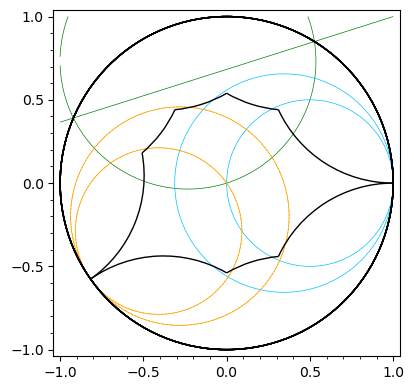

In [46]:
good_side_pairings2=[]

for g in side_pairings2:
    if g.classification()=='hyperbolic' or g.classification()=='orientation-reversing hyperbolic':
        good_side_pairings2.append(g)

polygon_bananas2=polygon2
col2=['deepskyblue','green','violet','orange']

polygon_bananas2+=banana(good_side_pairings2[0],2*radius,col2[1])

for j in [0..1]:
    polygon_bananas2+=bananapar(0,distances_list_ref2,j,col2[0])
    polygon_bananas2+=bananapar(2*beta+4*alpha,distances_list_ref2,j,col2[3])

polygon_bananas2.show(ymax=1, ymin=-1)

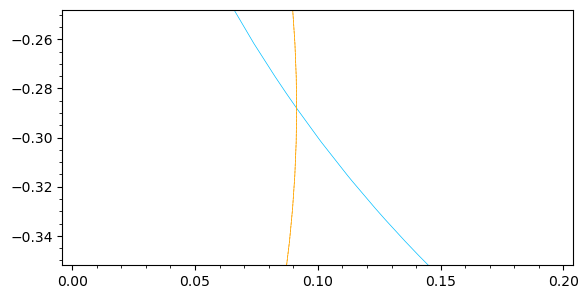

In [47]:
polygon_bananas2.show(ymax=-0.25, ymin=-0.35, xmax=0.2, xmin=0)

As fd_first_distance and fd_second_distance are the two smallest admissible distances, we do not have to calculate more bananas: if d1\<d2, the bananas of a hyperbolic isometry (or glide reflection) s associated to the distance d1 are contained in the region bounded by the bananas of s associated to the distance d2, while the banana of a parabolic transformation s associated to d1 is a horocycle contained in the horoball bounded by the banana of s associated to the distance d2. Therefore, as the closure of the regions bounded by the bananas represented in the previous figure cover all the fundamental domain, we do not have to take more bananas: if a point is at the interior of the region bounded by the bananas associated to the distance fd_first_distance, there is no admissible banana of this side-pairing that passes through this point and the same happens in the interior of the region bounded by each of the parabolic bananas associated to fd_second_distance minus the region bounded by the corresponding parabolic banana  associated to fd_first_distance.

In particular, the preimages of the extremal disc centers must be on the bananas illustrated in the previous figure. In fact, if we consider the open sets given by the interior of the regions described previously and we take their union, we will be covering all the points of the fundamental domain except two, one of them the origin (which we know is the preimage of an extremal disc centre by construction). Therefore, we only need to analyse the situation of the other special point, which is the only other candidate to be the preimage of an extremal disc center. In the previous figure, the blue and yellow first admissible bananas are intersecting in this point. We will see that if we consider more admissible bananas, there is also a banana of each of the other side-pairings passing through it.

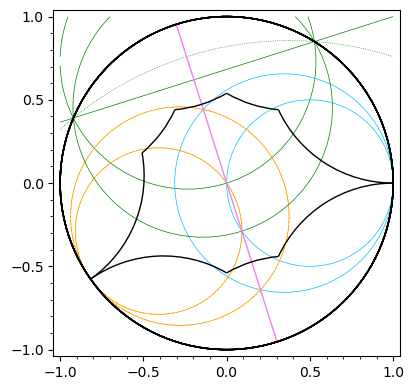

In [48]:
polygon_bananas2_2=polygon_bananas2+banana(good_side_pairings2[1],2*radius,'violet')+banana(good_side_pairings2[0],fd_second_distance,'green')

polygon_bananas2_2.show(ymax=1, ymin=-1)

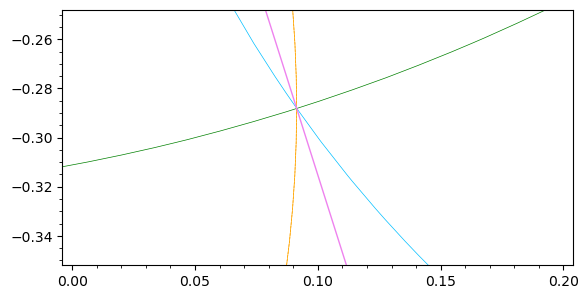

In [49]:
polygon_bananas2_2.show(ymax=-0.25, ymin=-0.35, xmax=0.2, xmin=0) #We have a candidate!

There are bananas of all the colors intersecting in the unique possible candidate (distinct to the origin) for being the preimage of an extremal disc center in the fundamental domain. We are going to study the situation at this point.

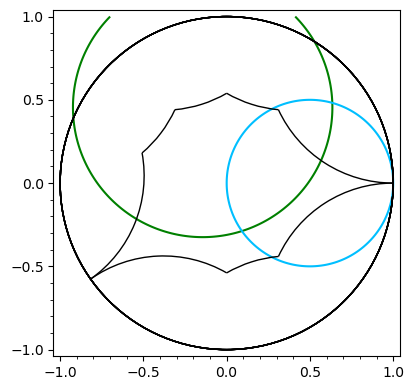

In [50]:
banana1_2=banana(good_side_pairings2[0],fd_second_distance)[0]
banana2_2=bananapar(0,distances_list_ref2,0)[1]==0

implicit_plot(banana1_2,(x, -1, 1),(y, -1, 1),color=col2[1])+implicit_plot(banana2_2,(x, -1, 1),(y, -1, 1),color=col2[0])+polygon2

In [51]:
intersection2=coord_intersection(banana1_2,banana2_2)
intersection2

[0.0914086767466147 - 0.288189400502599*I,
 0.634365293013543 + 0.481607691003149*I]

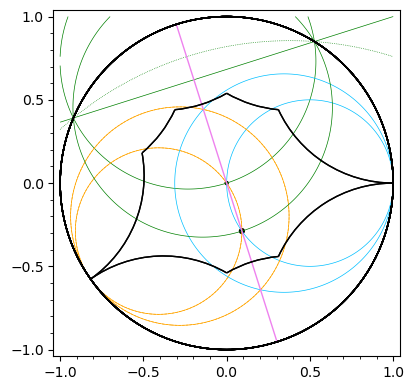

In [52]:
intersection_p2=intersection2[0]
bananas_point2=polygon2+polygon_bananas2_2+points([intersection_p2],color='black', size='20')+points([0+0*I],color='black')
bananas_point2.show(ymin=-1,ymax=1)

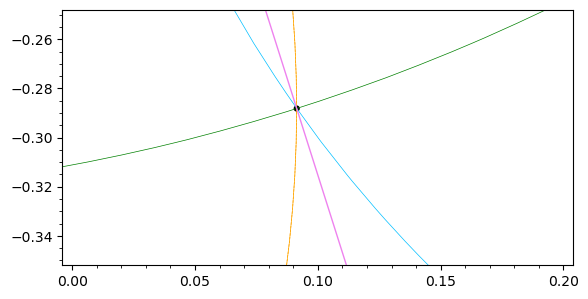

In [53]:
bananas_point2.show(ymax=-0.25, ymin=-0.35, xmax=0.2, xmin=0)

In [54]:
#Check if the rotation of angle pi around the origin defines an automorphism of the surface.
rot2=rotationpi(0+0*I, intersection_p2)
geod2=PD.get_geodesic(PD.get_point(0+0*I), PD.get_point(intersection_p2))
fixed_p2=geod2.midpoint().coordinates()

intersection_p2, fixed_p2

(0.0914086767466147 - 0.288189400502599*I,
 0.04679943178081098 - 0.1475472643167172*I)

In [55]:
#The following function find out if an isometry conjugates another isometry in an element of a fixed list of isometries.
#Inputs: generators (list of isometries of the hyperbolic plane), isometries (list of isometries of the hyperbolic plane), aut (isometry of the hyperbolic plane), k ('int')
#Outputs: A message about if g=aut*generators[k]*aut^(-1) equals some element in isometries or it is impossible to occur because metric conditions (it does not respect the tessellation defined by generators).
#In any of the previous cases, it returns the isometry h that give us the information and plot the image of the fundamental domain by h^(-1)*g.

def check_conj2(generators,isometries,aut,k):
    conj=aut*generators[k]*aut^(-1)
    k=0
    test=0
    
    while k<len(isometries) and test==0:
        dist=origin.dist(isometries[k]^(-1)*conj*origin)
        if dist<radius:
            test=1
        k+=1
    
    if test==0: print("We have arrived to the end of the list without finding any element that confirms or denies anything.")
    else:
        print("The right element corresponds to the position ", k-1)
        print("The isometry is given by: ", isometries[k-1])
        if dist<10^(-6) and PD(1/2).dist((isometries[k-1]^(-1)*conj)*PD(1/2))<10^(-6) and (isometries[k-1]^(-1)*conj).preserves_orientation()==True:
            print("It conjugates well.")
        show(polygon2+movepolygon2((isometries[k-1]^(-1)*conj), 'skyblue'))

Checking if rot2 conjugates properly the side-pairing transformation number  0
The right element corresponds to the position  0
The isometry is given by:  Isometry in PD
[-0.999999999999999 - 1.31718264650678*I  0.759196154498422 - 1.07637880100520*I]
[ 0.759196154498422 + 1.07637880100520*I -0.999999999999999 + 1.31718264650678*I]
It conjugates well.


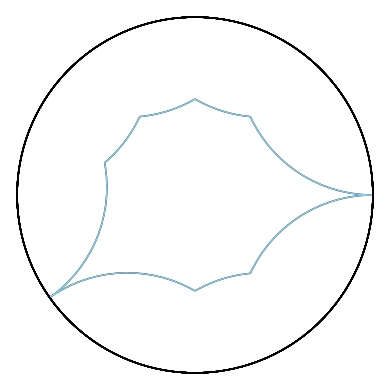

Checking if rot2 conjugates properly the side-pairing transformation number  1
The right element corresponds to the position  10
The isometry is given by:  Isometry in PD
[-0.817182646506786 + 2.57637880100522*I  2.39356144751199 + 0.759196154498434*I]
[-2.39356144751199 + 0.759196154498434*I  0.817182646506786 + 2.57637880100522*I]
It conjugates well.


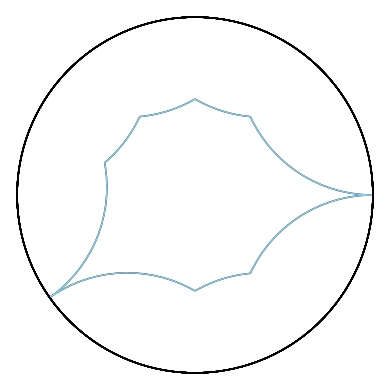

Checking if rot2 conjugates properly the side-pairing transformation number  2
The right element corresponds to the position  6
The isometry is given by:  Isometry in PD
[    1.57637880100520 + 0.500000000000001*I  6.10622663543836e-16 - 1.31718264650678*I]
[-6.10622663543836e-16 - 1.31718264650678*I    -1.57637880100520 + 0.500000000000001*I]
It conjugates well.


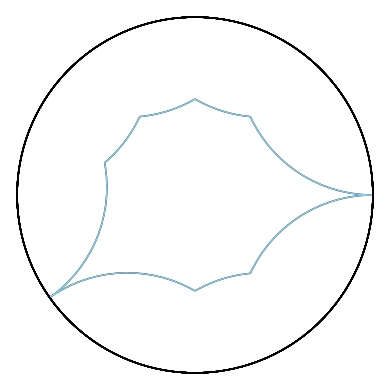

Checking if rot2 conjugates properly the side-pairing transformation number  3
The right element corresponds to the position  8
The isometry is given by:  Isometry in PD
[ 0.817182646506763 - 2.57637880100522*I -2.39356144751199 + 0.759196154498433*I]
[ 2.39356144751199 + 0.759196154498433*I -0.817182646506763 - 2.57637880100522*I]
It conjugates well.


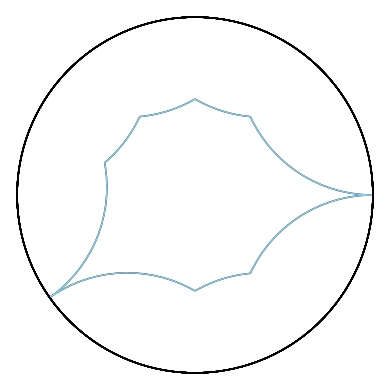

Checking if rot2 conjugates properly the side-pairing transformation number  4
The right element corresponds to the position  2
The isometry is given by:  Isometry in PD
[  -0.999999999999998 + 1.31718264650678*I 9.99200722162641e-16 - 1.31718264650677*I]
[9.99200722162641e-16 + 1.31718264650677*I   -0.999999999999998 - 1.31718264650678*I]
It conjugates well.


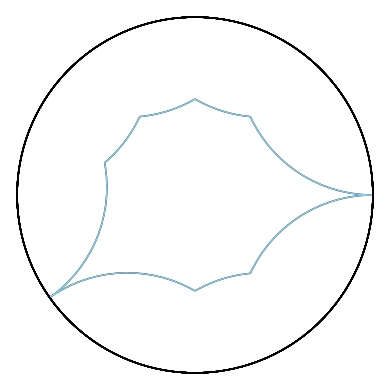

Checking if rot2 conjugates properly the side-pairing transformation number  5
The right element corresponds to the position  1
The isometry is given by:  Isometry in PD
[     1.00000000000000 + 1.31718264650678*I -1.11022302462516e-15 - 1.31718264650677*I]
[-1.11022302462516e-15 + 1.31718264650677*I      1.00000000000000 - 1.31718264650678*I]
It conjugates well.


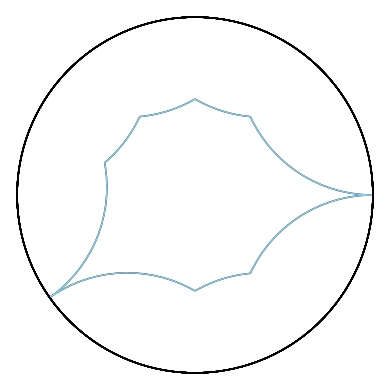

Checking if rot2 conjugates properly the side-pairing transformation number  6
The right element corresponds to the position  7
The isometry is given by:  Isometry in PD
[     -1.576378801005205 - 0.4999999999999999*I  3.0531133177191805e-16 - 1.3171826465067815*I]
[-3.0531133177191805e-16 - 1.3171826465067815*I       1.576378801005205 - 0.4999999999999999*I]
It conjugates well.


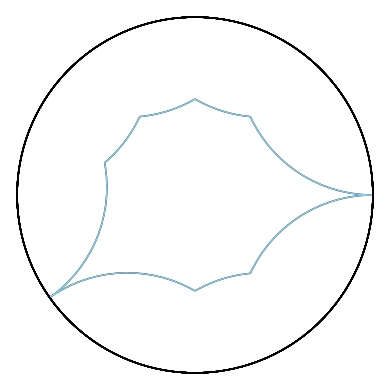

Checking if rot2 conjugates properly the side-pairing transformation number  7
The right element corresponds to the position  3
The isometry is given by:  Isometry in PD
[ 1.00000000000000 - 1.31718264650678*I 0.759196154498422 - 1.07637880100520*I]
[0.759196154498422 + 1.07637880100520*I  1.00000000000000 + 1.31718264650678*I]
It conjugates well.


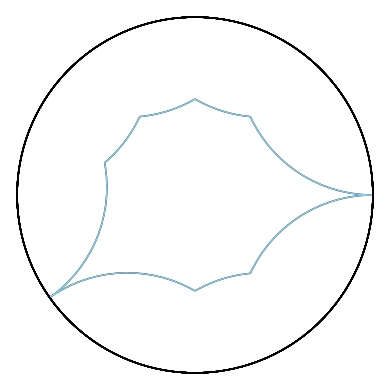

In [56]:
candidate_aut2=rot2
for j in [0..m-1]:
    print('Checking if rot2 conjugates properly the side-pairing transformation number ', j)
    check_conj2(side_pairings2,isometries_t2,candidate_aut2, j)

In the eight previous cases, the algorithm of check_conj2 converges and mustbeidentity is an isometry that fixes at least two points and preserves the orientation, so mustbeidentity==Id. Therefore, candidate_aut2 belongs to the normalizer of the uniformizating group and it defines an automorphism of the surface.

Moreover, the image of the projection of the origin by this automorphism is also an extremal disc center and intersection_p2 is a preimage of this point. As the origin and intersection_p2 were the only candidates to be the preimage of an extremal disc center in the fundamental domain, the extremal projective plane with two cusps defined by this extremal disc configuration has exactly two extremal discs, centered at the projections of the origin and intersection_p2.

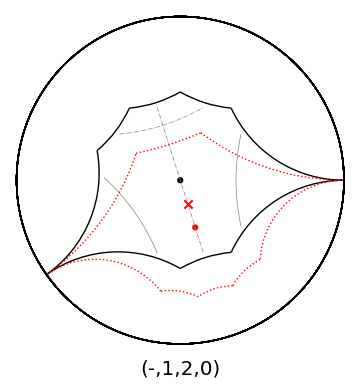

In [57]:
identifications_g2=plot(PD.get_geodesic(fd_midpoints2[0],fd_midpoints2[1]), color='gray', thickness=0.5)
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[2],fd_midpoints2[4]), color='gray', linestyle='-.', thickness=0.5)
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[3],fd_midpoints2[7]), color='gray', linestyle='-.',thickness=0.5)
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[5],fd_midpoints2[6]), color='gray', thickness=0.5)

polygon_art2=polygon2+points([intersection_p2], color='red',size=20)+points([0+0*I], color='black', size=20)+identifications_g2
polygon_art2+=points([fixed_p2], marker='x', size=35, color='red')+text('(-,1,2,0)', (0,-1.15), fontsize='x-large', color='black')
polygon_art2+=movepolygon2(candidate_aut2,'red',':')
polygon_art2

In order to look for the candidates to be preimages of the extremal disc centers in the extremal surfaces defined by both extremal disc configurations we only have considered bananas associated to the first two admissible distances, which only depend on the topological type and, therefore, they coincide in both cases. Indead, if we had cosidered the admissible distances in distances_list_ref2 in the first configuration (resp. the admissible distances in distances_list_ref in the second configuration) we have obtained the same candidates to be preimages of extremal disc centers, but we know that the Dirichlet domains centered at these candidates have the first configuration (resp. the second configuration) due to the existance of the automorphism we have found. Then, there are no extremal disc center in the surface defined by the first configuration such that the Dirichlet domain centered at its preimage has the second configuration, showing that each extremal disc configuration will define a different extremal surface, ie. there are exactly two extremal projective planes with two punctures.